# 🩺 Diabetes Prediction

This notebook presents a complete machine learning pipeline developed for competition on health data. The goal is to predict the probability of a diabetes diagnosis from a set of patient health indicators, using a synthetically generated dataset derived from the Diabetes Health Indicators Dataset.

The work is structured to cover the full ML workflow: exploratory analysis, preprocessing, feature engineering, model training and comparison, evaluation and final prediction.

**Source competition**: https://www.kaggle.com/competitions/playground-series-s5e12

**Author**: Sansone Lorenzo — University of Bologna, Academic Year 2025/2026

## 🗺️ Notebook Structure

1. Introduction
2. Setup
3. Exploratory of Data & Cleaning
4. Preprocessing & Feature Engineering
5. Baseline Model
6. Model Training & Comparison
7. Evaluation
8. Model Selection & Ensemble
9. Prediction & Submission
10. Conclusions
11. References

## **1. Introduction**

This notebook addresses a binary classification problem: **predicting the probability that a patient has been diagnosed with diabetes**, based on a set of health indicators.

The dataset was synthetically generated from a deep learning model trained on the [Diabetes Health Indicators Dataset](https://www.kaggle.com/datasets/mohankrishnathalla/diabetes-health-indicators-dataset/data), meaning feature distributions are close — but not identical — to the original.

---

### 1.1 Objective
The goal of this competition is to leverage machine learning techniques to predict the probability that a patient will be diagnosed with diabetes based on various clinical and demographic features.

Predict the **probability** of `diagnosed_diabetes` for each sample in the test set.  
The primary evaluation metric is **ROC-AUC** (Area Under the Receiver Operating Characteristic Curve).

---

### 1.2 Files
| File | Description |
|---|---|
| `train.csv` | Training set with features and target label |
| `test.csv` | Test set — features only, no labels |
| `sample_submission.csv` | Expected output format for predictions |


## **2. Setup**

### 2.1 Install Missing Dependencies (if needed)

The cell below installs any libraries not available by default in the environment.  
If you're running this on Kaggle or Google Colab, most of these are pre-installed.

In [59]:
# Install libraries not available by default
# Uncomment as needed depending on the environment

# !pip install numpy
# !pip install -U scikit-learn
# !pip install pandas
# !pip install seaborn

### 2.2 Import Libraries

In [83]:
# ── Core ──────────────────────────────────────────────────────────────────────
import numpy as np                          # Numerical operations
import pandas as pd                         # Data manipulation
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder # Encoding features

# ── Visualization ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt             # Base plotting library
import matplotlib.ticker as mticker
import seaborn as sns                       # Statistical visualizations

# ── Utilities ─────────────────────────────────────────────────────────────────
import os
import time
from IPython.display import display
import warnings


warnings.simplefilter(action='ignore', category=FutureWarning)
print("✅ All libraries imported successfully.")

✅ All libraries imported successfully.


### 2.3 Global Configuration

Centralizing configuration constants makes experiments reproducible and easy to tweak.
- `RANDOM_STATE`: fixes all stochastic operations so results are reproducible
- `TRAIN`:
- `N_FOLDS`: number of folds for cross-validation
- `TEST_SIZE`: fraction of training data used for the local validation set
- `TARGET`: name of the column we want to predict

In [61]:
# ── Reproducibility ───────────────────────────────────────────────────────────
RANDOM_STATE = 42           # Fixed seed for all random operations
np.random.seed(RANDOM_STATE)

# ── Hold-Out Method ───────────────────────────────────────────────────────────
TRAIN = 0.6

# ── Cross-Validation ──────────────────────────────────────────────────────────
N_FOLDS = 5                 # Number of StratifiedKFold folds

# ── Dataset ───────────────────────────────────────────────────────────────────
TARGET = 'diagnosed_diabetes'   # Name of the target column
DATA_DIR = '/kaggle/input/competitions/playground-series-s5e12' #Adjust according the dataset location 

print(f"✅ Configuration set:")
print(f"   Random state : {RANDOM_STATE}")
print(f"   CV folds     : {N_FOLDS}")
print(f"   Target col   : '{TARGET}'")

✅ Configuration set:
   Random state : 42
   CV folds     : 5
   Target col   : 'diagnosed_diabetes'


### 2.4 Load the Data

We load the train CSV files provided by the competition:
- `train.csv`: used to train, validate and test our models

In [62]:
# ── Load Datasets ─────────────────────────────────────────────────────────────
df = pd.read_csv(f'{DATA_DIR}/train.csv')

print("✅ Files loaded successfully.")
print(f"\n{'Dataset':<22} {'Rows':>8} {'Columns':>10}")
print("-" * 42)
print(f"{'train.csv':<22} {df.shape[0]:>8} {df.shape[1]:>10}")

✅ Files loaded successfully.

Dataset                    Rows    Columns
------------------------------------------
train.csv                700000         26


## **3. Exploration of Data & Cleaning**
Before any statistical analysis, we take a first look at the raw data to verify
it matches what the competition describes: correct number of rows and columns,
expected feature names, and sensible values at a glance.

### 3.1 General information about dataset
The dataset includes patient profiles with features based on **demographics**, **lifestyle habits**, **family history** and **clinical measurements** that are well-established indicators of diabetes risk.

All data has been synthetically generated using statistical distributions and correlations derived from real-world medical research studies. This approach ensures:

- 🔒 Privacy preservation (no real patient data used)
- 📊 Realistic health patterns and relationships
- 🧪 Suitability for machine learning, analysis, and experimentation

Display th list of columns

In [63]:
df.columns

Index(['id', 'age', 'alcohol_consumption_per_week',
       'physical_activity_minutes_per_week', 'diet_score',
       'sleep_hours_per_day', 'screen_time_hours_per_day', 'bmi',
       'waist_to_hip_ratio', 'systolic_bp', 'diastolic_bp', 'heart_rate',
       'cholesterol_total', 'hdl_cholesterol', 'ldl_cholesterol',
       'triglycerides', 'gender', 'ethnicity', 'education_level',
       'income_level', 'smoking_status', 'employment_status',
       'family_history_diabetes', 'hypertension_history',
       'cardiovascular_history', 'diagnosed_diabetes'],
      dtype='object')

#### Column Descriptions:

The dataset contains **26 columns** (25 features + 1 target), covering four
domains: clinical measurements, lifestyle habits, demographic information and personal medical history.

Note: since the `id` is just a unique row identifier, it carries no predictive value and it's not considered in the following description of the columns. So totally, we have 25 columns (24 features + 1 target) to analyze


##### 📊 Clinical Measurements
| Column | Type | Description |
|--------|------|-------------|
| `bmi` | float64 | Body Mass Index (kg/m²). |
| `waist_to_hip_ratio` | float64 | Ratio of waist circumference to hip circumference. |
| `systolic_bp` | int64 | Systolic blood pressure (mmHg) |
| `diastolic_bp` | int64 | Diastolic blood pressure (mmHg) |
| `heart_rate` | int64 | Resting heart rate (bpm - beats per minute). |
| `cholesterol_total` | int64 | Total cholesterol level (mg/dL). |
| `hdl_cholesterol` | int64 | High-Density Lipoprotein (HDL) cholesterol (mg/dL), commonly called "good" cholesterol. |
| `ldl_cholesterol` | int64 | Low-Density Lipoprotein cholesterol (mg/dL), commonly called "bad" cholesterol. |
| `triglycerides` | int64 | Triglyceride level (mg/dL), the most common type of fat in the blood.  |

---

##### 🏃 Lifestyle Habits
| Column | Type | Description |
|--------|------|-------------|
| `alcohol_consumption_per_week` | int64 | Number of alcoholic drinks consumed per week. |
| `physical_activity_minutes_per_week` | int64 | Total minutes of physical activity per week. |
| `diet_score` | float64 | A score reflecting overall dietary quality. Higher scores indicate a healthier diet. |
| `sleep_hours_per_day` | float64 | Average daily sleep hours. |
| `screen_time_hours_per_day` | float64 | Average daily hours spent on screens. |
| `smoking_status` | object | Smoking behavior ('Never', 'Former', 'Current') |

---

##### 👤 Demographic Information
| Column | Type | Description |
|--------|------|-------------|
| `age` | int64 | Age of the patient in years. |
| `gender` | object | Biological sex of the patient ( 'Male', 'Female', 'Other'). |
| `ethnicity` | object | Ethnic background ('White', 'Hispanic', 'Black', 'Asian', 'Other'). |
| `education_level` | object | Highest level of education completed. ('No formal', 'Highschool', 'Graduate', 'Postgraduate') |
| `income_level` | object | Income of the patient.  Likely **ordinal** ( 'Low' < 'Lower-Middle' < 'Middle' < 'Upper-Middle'< 'High' ) |
| `employment_status` | object | Current employment situation ('Employed', 'Unemployed', 'Retired', 'Student'). |

---

##### 🏥 Medical History
| Column | Type | Description |
|--------|------|-------------|
| `family_history_diabetes` | int64 | Binary flag (0 = No, 1 = Yes) indicating family history of diabetes. |
| `hypertension_history` | int64 | Binary flag (0 = No, 1 = Yes) indicating a diagnosis of hypertension. |
| `cardiovascular_history` | int64 | Binary flag (0 = No, 1 = Yes) indicating a history of cardiovascular disease. |

---

##### 🎯 Target Variable
| Column | Type | Description |
|--------|------|-------------|
| `diagnosed_diabetes` | float64 | Binary target variable (0.0 = No diabetes, 1.0 = Diabetes). This is the variable our models will learn to predict. |

Display the first 5 rows to get a feel for the data:

In [64]:
df.head()

,id,age,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,sleep_hours_per_day,screen_time_hours_per_day,bmi,waist_to_hip_ratio,systolic_bp,...,gender,ethnicity,education_level,income_level,smoking_status,employment_status,family_history_diabetes,hypertension_history,cardiovascular_history,diagnosed_diabetes
0,0,31,1,45,7.7,6.8,6.1,33.4,0.93,112,...,Female,Hispanic,Highschool,Lower-Middle,Current,Employed,0,0,0,1.0
1,1,50,2,73,5.7,6.5,5.8,23.8,0.83,120,...,Female,White,Highschool,Upper-Middle,Never,Employed,0,0,0,1.0
2,2,32,3,158,8.5,7.4,9.1,24.1,0.83,95,...,Male,Hispanic,Highschool,Lower-Middle,Never,Retired,0,0,0,0.0
3,3,54,3,77,4.6,7.0,9.2,26.6,0.83,121,...,Female,White,Highschool,Lower-Middle,Current,Employed,0,1,0,1.0
4,4,54,1,55,5.7,6.2,5.1,28.8,0.90,108,...,Male,White,Highschool,Upper-Middle,Never,Retired,0,1,0,1.0


`df.info()` gives a compact structural summary of the dataframe:
- total number of rows and columns
- each column's name, non-null count, and dtype
- memory usage

In [65]:
df.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 700000 entries, 0 to 699999
Data columns (total 26 columns):
 #   Column                              Non-Null Count   Dtype  
---  ------                              --------------   -----  
 0   id                                  700000 non-null  int64  
 1   age                                 700000 non-null  int64  
 2   alcohol_consumption_per_week        700000 non-null  int64  
 3   physical_activity_minutes_per_week  700000 non-null  int64  
 4   diet_score                          700000 non-null  float64
 5   sleep_hours_per_day                 700000 non-null  float64
 6   screen_time_hours_per_day           700000 non-null  float64
 7   bmi                                 700000 non-null  float64
 8   waist_to_hip_ratio                  700000 non-null  float64
 9   systolic_bp                         700000 non-null  int64  
 10  diastolic_bp                        700000 non-null  int64  
 11  heart_rate                

**Observations:**

The dataset contains **700,000 rows and 26 columns** with **no missing values** across
any feature.

The columns fall into three groups by dtype:

- **Continuous numerical** (`float64`)

- **Discrete numerical** (`int64`)

- **Categorical** (`object`)


The **target** `diagnosed_diabetes` is stored as `float64` rather than `int64`. It should contain only `0.0` and `1.0` values (see later).

The total memory footprint is **138.9 MB**, manageable in-memory without
any chunking strategy.

Overall check of type and non-unique features:

In [66]:
pd.DataFrame({
    'dtype':   df.dtypes,
    'nunique': df.nunique(),
    'sample':  [df[c].dropna().iloc[0] if df[c].notna().any() else None for c in df.columns]
})

,dtype,nunique,sample
id,int64,700000,0
age,int64,71,31
alcohol_consumption_per_week,int64,9,1
physical_activity_minutes_per_week,int64,565,45
diet_score,float64,99,7.7
sleep_hours_per_day,float64,69,6.8
screen_time_hours_per_day,float64,151,6.1
bmi,float64,231,33.4
waist_to_hip_ratio,float64,36,0.93
systolic_bp,int64,71,112


Check the **object** features:

In [67]:
categorical_cols = df.select_dtypes('object').columns.to_list()

# category values with relative frequencies (to spot class imbalance inside a feature)
for col in categorical_cols:
    print(f"\n \033[1m--- 📋 {col}  ({len(df[col].unique())} unique elements)\033[0m ---")
    print(df[col].value_counts(normalize=True, dropna=False).mul(100).round(2).astype(str) + ' %')


 --- 📋 gender  (3 unique elements) ---
gender
Female    51.89 %
Male      47.58 %
Other      0.53 %
Name: proportion, dtype: object

 --- 📋 ethnicity  (5 unique elements) ---
ethnicity
White       55.16 %
Hispanic    18.57 %
Black       15.19 %
Asian        8.59 %
Other        2.49 %
Name: proportion, dtype: object

 --- 📋 education_level  (4 unique elements) ---
education_level
Highschool      49.16 %
Graduate        37.32 %
Postgraduate    11.38 %
No formal        2.14 %
Name: proportion, dtype: object

 --- 📋 income_level  (5 unique elements) ---
income_level
Middle          41.51 %
Lower-Middle    25.51 %
Upper-Middle    18.26 %
Low             12.26 %
High             2.46 %
Name: proportion, dtype: object

 --- 📋 smoking_status  (3 unique elements) ---
smoking_status
Never      70.64 %
Current    14.77 %
Former      14.6 %
Name: proportion, dtype: object

 --- 📋 employment_status  (4 unique elements) ---
employment_status
Employed      73.74 %
Retired       16.53 %
Unemployed   

Find hidden categoricals among the int64 and float64 columns. Many features in this dataset are likely binary flags (family history, etc.) 

In [68]:
#values with relative frequencies (to spot class imbalance inside a feature)
for col in df.select_dtypes(['int64','float64']).columns.to_list():
    n = df[col].nunique()
    if n <= 20:
        print(f"\n \033[1m--- 📋 {col} ({len(df[col].unique())} unique elements) --- \033[0m")
        print(df[col].value_counts(normalize=True, dropna=False).mul(100).round(2).astype(str) + ' %')


 --- 📋 alcohol_consumption_per_week (9 unique elements) --- 
alcohol_consumption_per_week
2    35.23 %
1    35.19 %
3    19.65 %
4     7.57 %
5      1.9 %
6     0.39 %
7     0.06 %
8     0.01 %
9      0.0 %
Name: proportion, dtype: object

 --- 📋 family_history_diabetes (2 unique elements) --- 
family_history_diabetes
0    85.06 %
1    14.94 %
Name: proportion, dtype: object

 --- 📋 hypertension_history (2 unique elements) --- 
hypertension_history
0    81.8 %
1    18.2 %
Name: proportion, dtype: object

 --- 📋 cardiovascular_history (2 unique elements) --- 
cardiovascular_history
0    96.97 %
1     3.03 %
Name: proportion, dtype: object

 --- 📋 diagnosed_diabetes (2 unique elements) --- 
diagnosed_diabetes
1.0    62.33 %
0.0    37.67 %
Name: proportion, dtype: object


Check for any duplicate row:

In [69]:
print(f"Exact duplicates: {df.drop(columns='id').duplicated().sum()}")


Exact duplicates: 0


The **describe** method of pandas dataframes gives a short summary

In [70]:
df.describe()

,id,age,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,sleep_hours_per_day,screen_time_hours_per_day,bmi,waist_to_hip_ratio,systolic_bp,diastolic_bp,heart_rate,cholesterol_total,hdl_cholesterol,ldl_cholesterol,triglycerides,family_history_diabetes,hypertension_history,cardiovascular_history,diagnosed_diabetes
count,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000
mean,349999.500000,50.359734,2.072411,80.230803,5.963695,7.002200,6.012733,25.874684,0.858766,116.294193,75.440924,70.167749,186.818801,53.823214,102.905854,123.081850,0.149401,0.181990,0.030324,0.623296
std,202072.738554,11.655520,1.048189,51.195071,1.463336,0.901907,2.022707,2.860705,0.037980,11.010390,6.825775,6.938722,16.730832,8.266545,19.022416,24.739397,0.356484,0.385837,0.171478,0.484560
min,0.000000,19.000000,1.000000,1.000000,0.100000,3.100000,0.600000,15.100000,0.680000,91.000000,51.000000,42.000000,117.000000,21.000000,51.000000,31.000000,0.000000,0.000000,0.000000,0.000000
25%,174999.750000,42.000000,1.000000,49.000000,5.000000,6.400000,4.600000,23.900000,0.830000,108.000000,71.000000,65.000000,175.000000,48.000000,89.000000,106.000000,0.000000,0.000000,0.000000,0.000000
50%,349999.500000,50.000000,2.000000,71.000000,6.000000,7.000000,6.000000,25.900000,0.860000,116.000000,75.000000,70.000000,187.000000,54.000000,103.000000,123.000000,0.000000,0.000000,0.000000,1.000000
75%,524999.250000,58.000000,3.000000,96.000000,7.000000,7.600000,7.400000,27.800000,0.880000,124.000000,80.000000,75.000000,199.000000,59.000000,116.000000,139.000000,0.000000,0.000000,0.000000,1.000000
max,699999.000000,89.000000,9.000000,747.000000,9.900000,9.900000,16.500000,38.400000,1.050000,163.000000,104.000000,101.000000,289.000000,90.000000,205.000000,290.000000,1.000000,1.000000,1.000000,1.000000


### 3.2 Clean data

Check for NaN or null values:

In [71]:
print('NaN count:', df.isnull().sum().sum(), '\n')
df.isnull().sum()

NaN count: 0 



id                                    0
age                                   0
alcohol_consumption_per_week          0
physical_activity_minutes_per_week    0
diet_score                            0
sleep_hours_per_day                   0
screen_time_hours_per_day             0
bmi                                   0
waist_to_hip_ratio                    0
systolic_bp                           0
diastolic_bp                          0
heart_rate                            0
cholesterol_total                     0
hdl_cholesterol                       0
ldl_cholesterol                       0
triglycerides                         0
gender                                0
ethnicity                             0
education_level                       0
income_level                          0
smoking_status                        0
employment_status                     0
family_history_diabetes               0
hypertension_history                  0
cardiovascular_history                0


There aren't any null or nan values so in this case we don't have to remove any rows

### 3.3 Target Variable Distribution & Class Balance

Before any modeling decision we need to understand how the two classes are distributed.
A strong imbalance would force us to use stratified splits, class-weighting, or resampling
techniques; a near-balanced target lets us train with standard procedures.

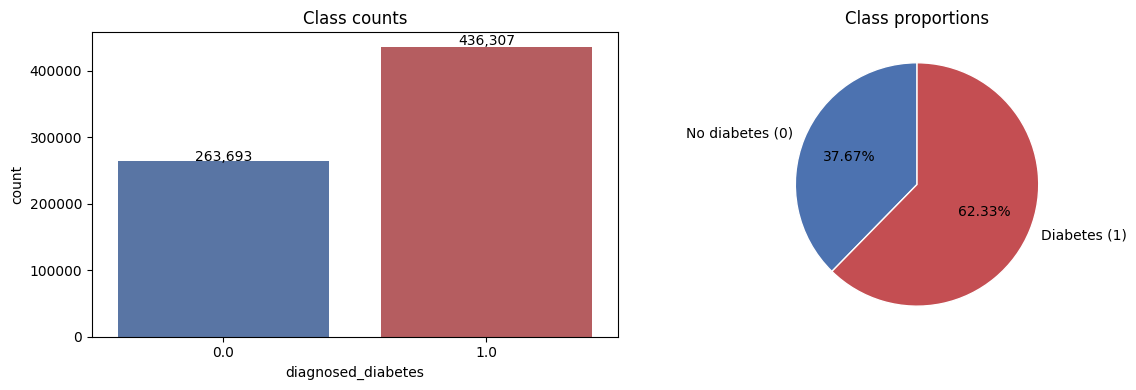

0 (no diabetes): 263693.00
1 (yes diabetes): 436307.00
Positive/Negative ratio: 1.65


In [72]:
# Plot class distribution of the target
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Countplot
counts = df[TARGET].value_counts().sort_index() # Take the counts of target values
sns.countplot(x=TARGET, data=df, ax=axes[0], palette=['#4C72B0', '#C44E52']) # Compute the histogram
axes[0].set_title('Class counts')
axes[0].set_xlabel('diagnosed_diabetes')
axes[0].set_ylabel('count')

# Text over the columns
no_diagn = 0
yes_diagn = 1
axes[0].text(0, counts.values[no_diagn] + counts.values[no_diagn]*0.005, f'{counts.values[no_diagn]:,}', ha='center', fontsize=10)
axes[0].text(1, counts.values[yes_diagn] + counts.values[yes_diagn]*0.005, f'{counts.values[yes_diagn]:,}', ha='center', fontsize=10)

# Pieplot with percentages
axes[1].pie(counts.values,
            labels=['No diabetes (0)', 'Diabetes (1)'],
            autopct='%1.2f%%',
            colors=['#4C72B0', '#C44E52'],
            startangle=90,
            wedgeprops={'edgecolor': 'white'})
axes[1].set_title('Class proportions')

plt.tight_layout()
plt.show()

ratio = counts[1.0] / counts[0.0]
print(f"0 (no diabetes): {counts[0.0]:.2f}")
print(f"1 (yes diabetes): {counts[1.0]:.2f}")
print(f"Positive/Negative ratio: {ratio:.2f}")

**Observations:**

- The target is **mildly imbalanced** (~62% positives, ~38% negatives).
- The positive class is the majority.

### 3.4 Numerical Features — Univariate Distributions

We separate truly *continuous* numerical features from *binary* flags (already inspected
above) and plot a histogram + KDE for each one to inspect the shape, symmetry, and the presence of suspicious peaks.

In [73]:
# Continuous numerical features (exclude id, target, binary flags, and low-card discretes)
binary_cols = ['family_history_diabetes', 'hypertension_history', 'cardiovascular_history']
discrete_cols = ['alcohol_consumption_per_week']
numeric_cols = [c for c in df.select_dtypes(include=['int64', 'float64']).columns
                if c not in ['id', TARGET] + binary_cols + discrete_cols]

print(f"Continuous numerical features ({len(numeric_cols)}):")
print(numeric_cols)

Continuous numerical features (14):
['age', 'physical_activity_minutes_per_week', 'diet_score', 'sleep_hours_per_day', 'screen_time_hours_per_day', 'bmi', 'waist_to_hip_ratio', 'systolic_bp', 'diastolic_bp', 'heart_rate', 'cholesterol_total', 'hdl_cholesterol', 'ldl_cholesterol', 'triglycerides']


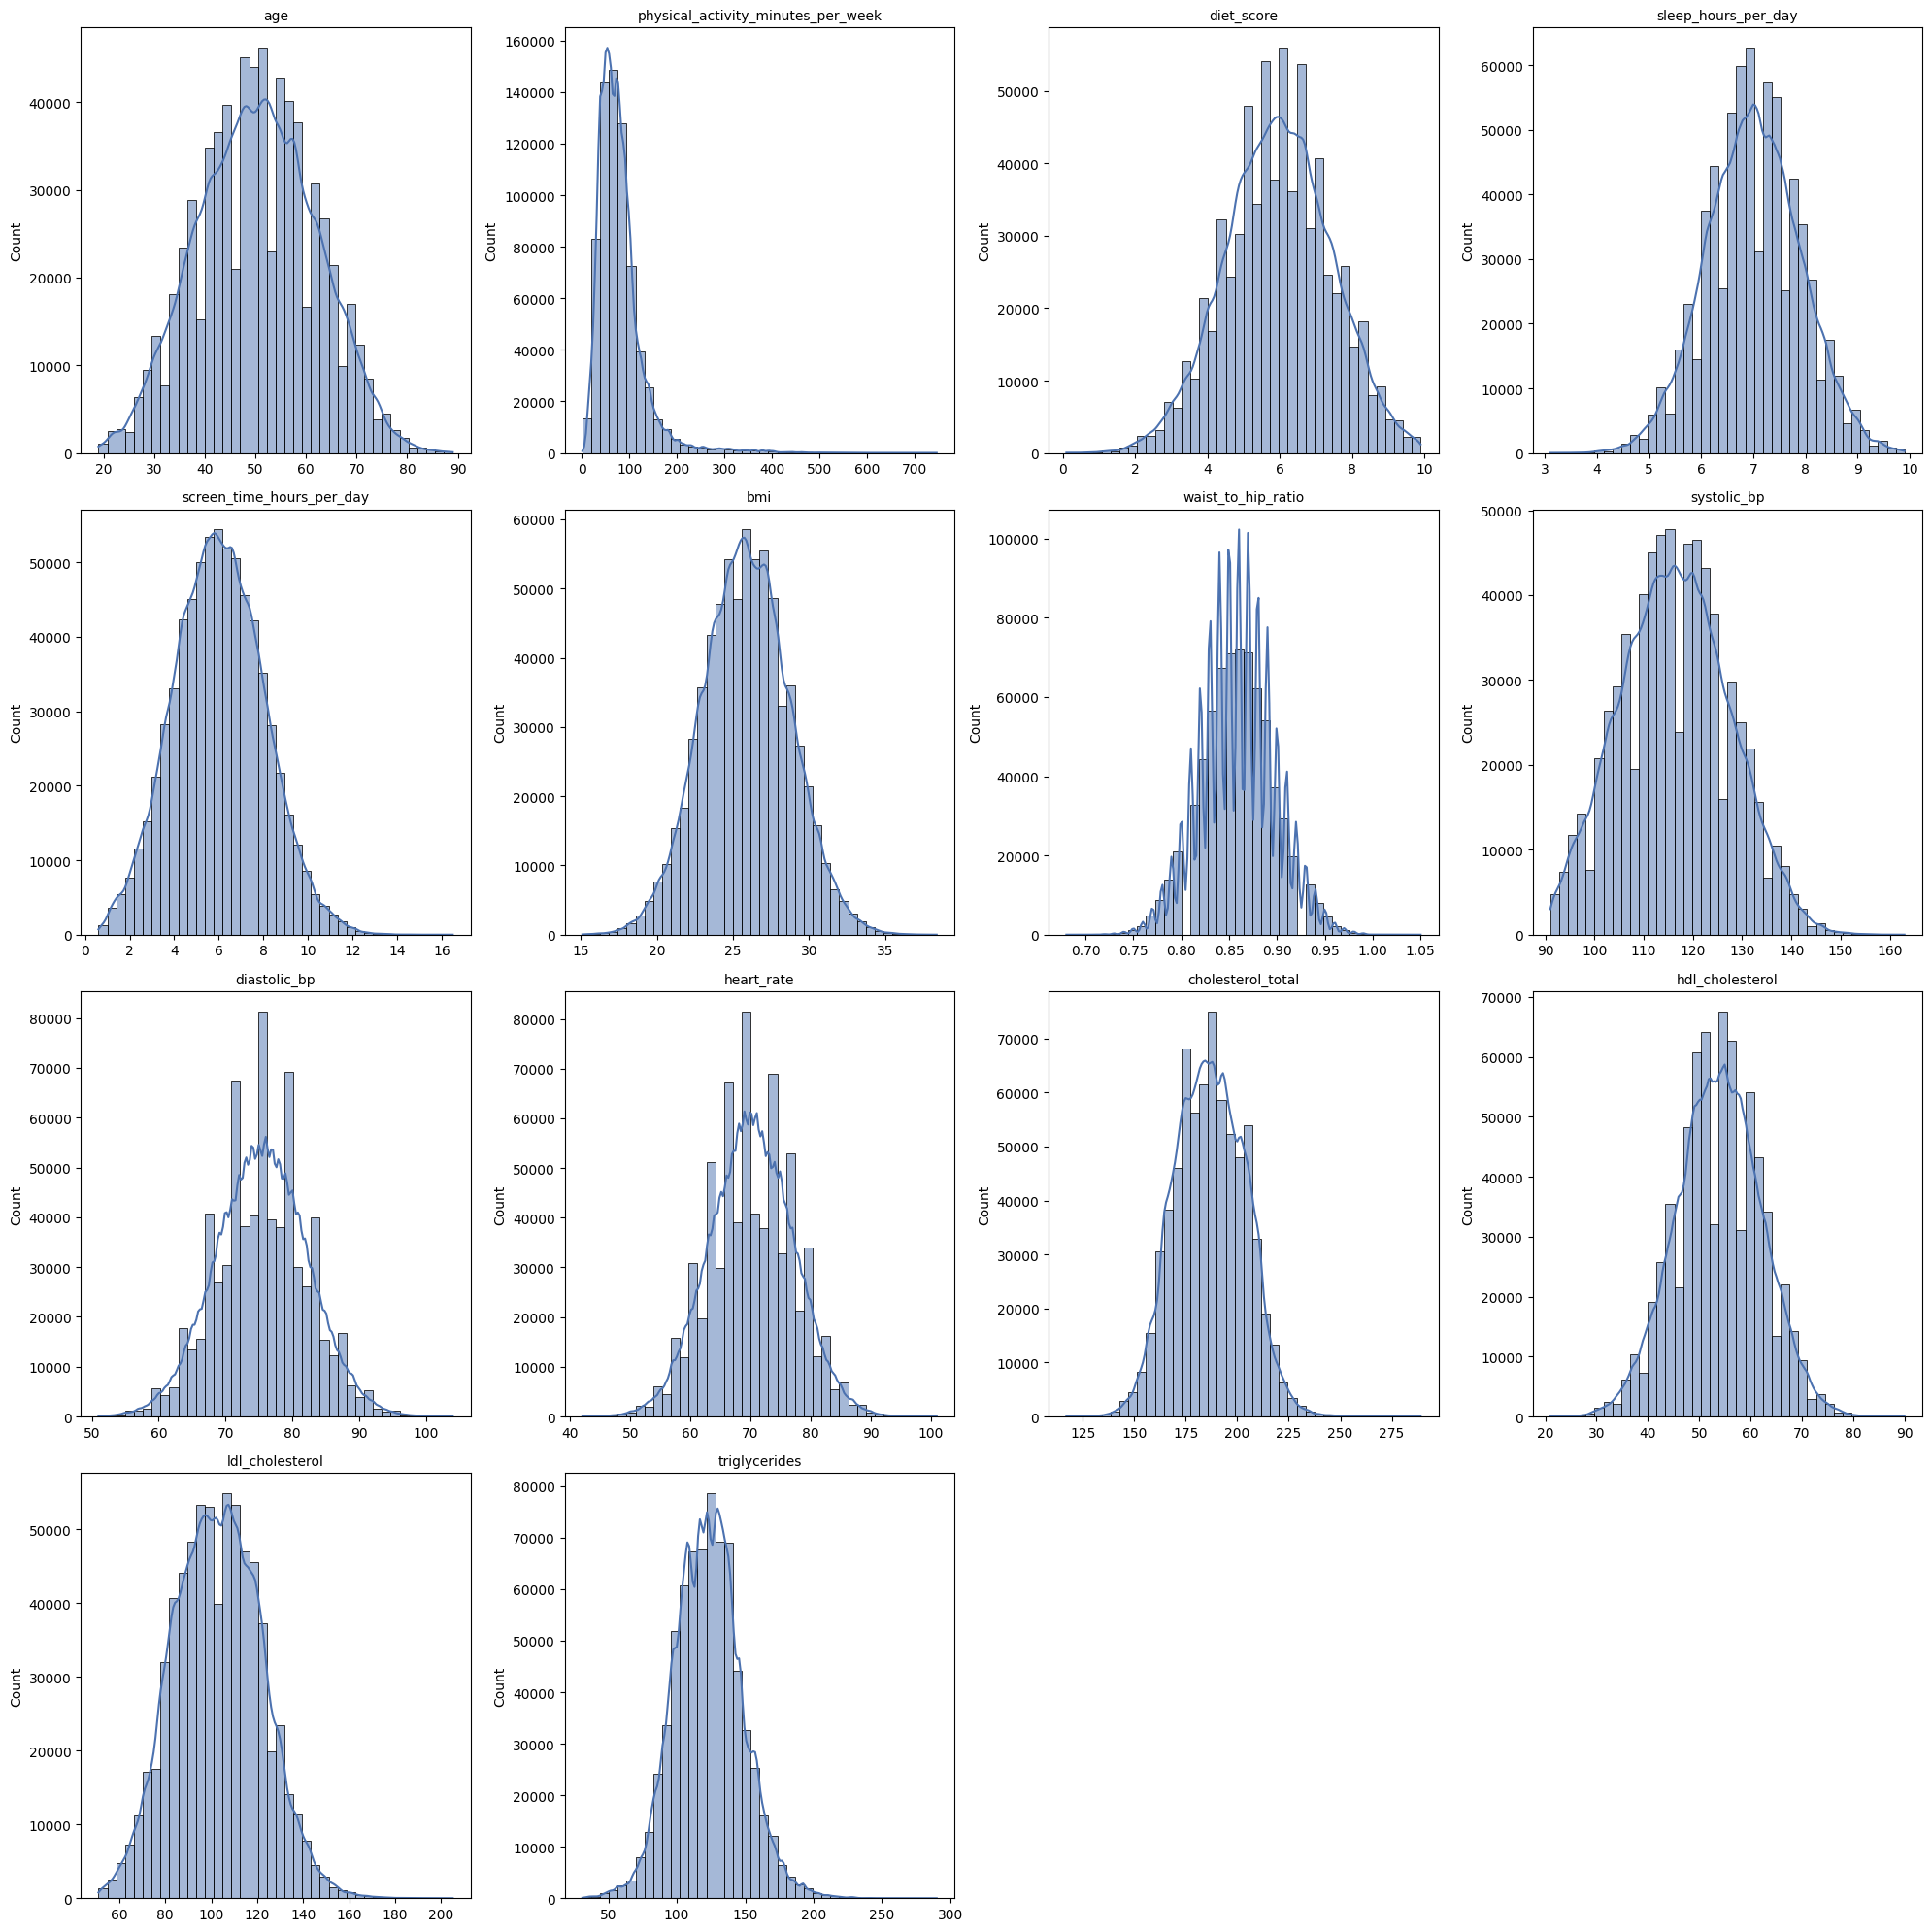

In [74]:
# Histograms with KDE for every continuous numerical feature
n_cols = 4
n_rows = 4
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 20))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], color='#4C72B0', bins=40)
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel('')

# Hide unused axes
for j in range(len(numeric_cols), len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

**Observation:**
- Most clinical features (`bmi`, `systolic_bp`, `diastolic_bp`, `heart_rate`,
  `cholesterol_total`, `hdl_cholesterol`, `ldl_cholesterol`, `triglycerides`,
  `waist_to_hip_ratio`) are roughly **bell-shaped**.
- `physical_activity_minutes_per_week` shows a **strong right-skew** with a long tail
  (a few people training >250 min/week).
- `diet_score`, `sleep_hours_per_day`, `screen_time_hours_per_day` look roughly
  symmetric.
- `age` is distributed between 19 and 89.

### 3.5 Outlier Detection (Boxplots + IQR rule)

We use the **interquartile range (IQR) rule**: a point is flagged as an outlier when it
falls outside `[Q1 − 1.5·IQR, Q3 + 1.5·IQR]`. The boxplots provide a visual confirmation;
the table quantifies how many points are flagged per feature.

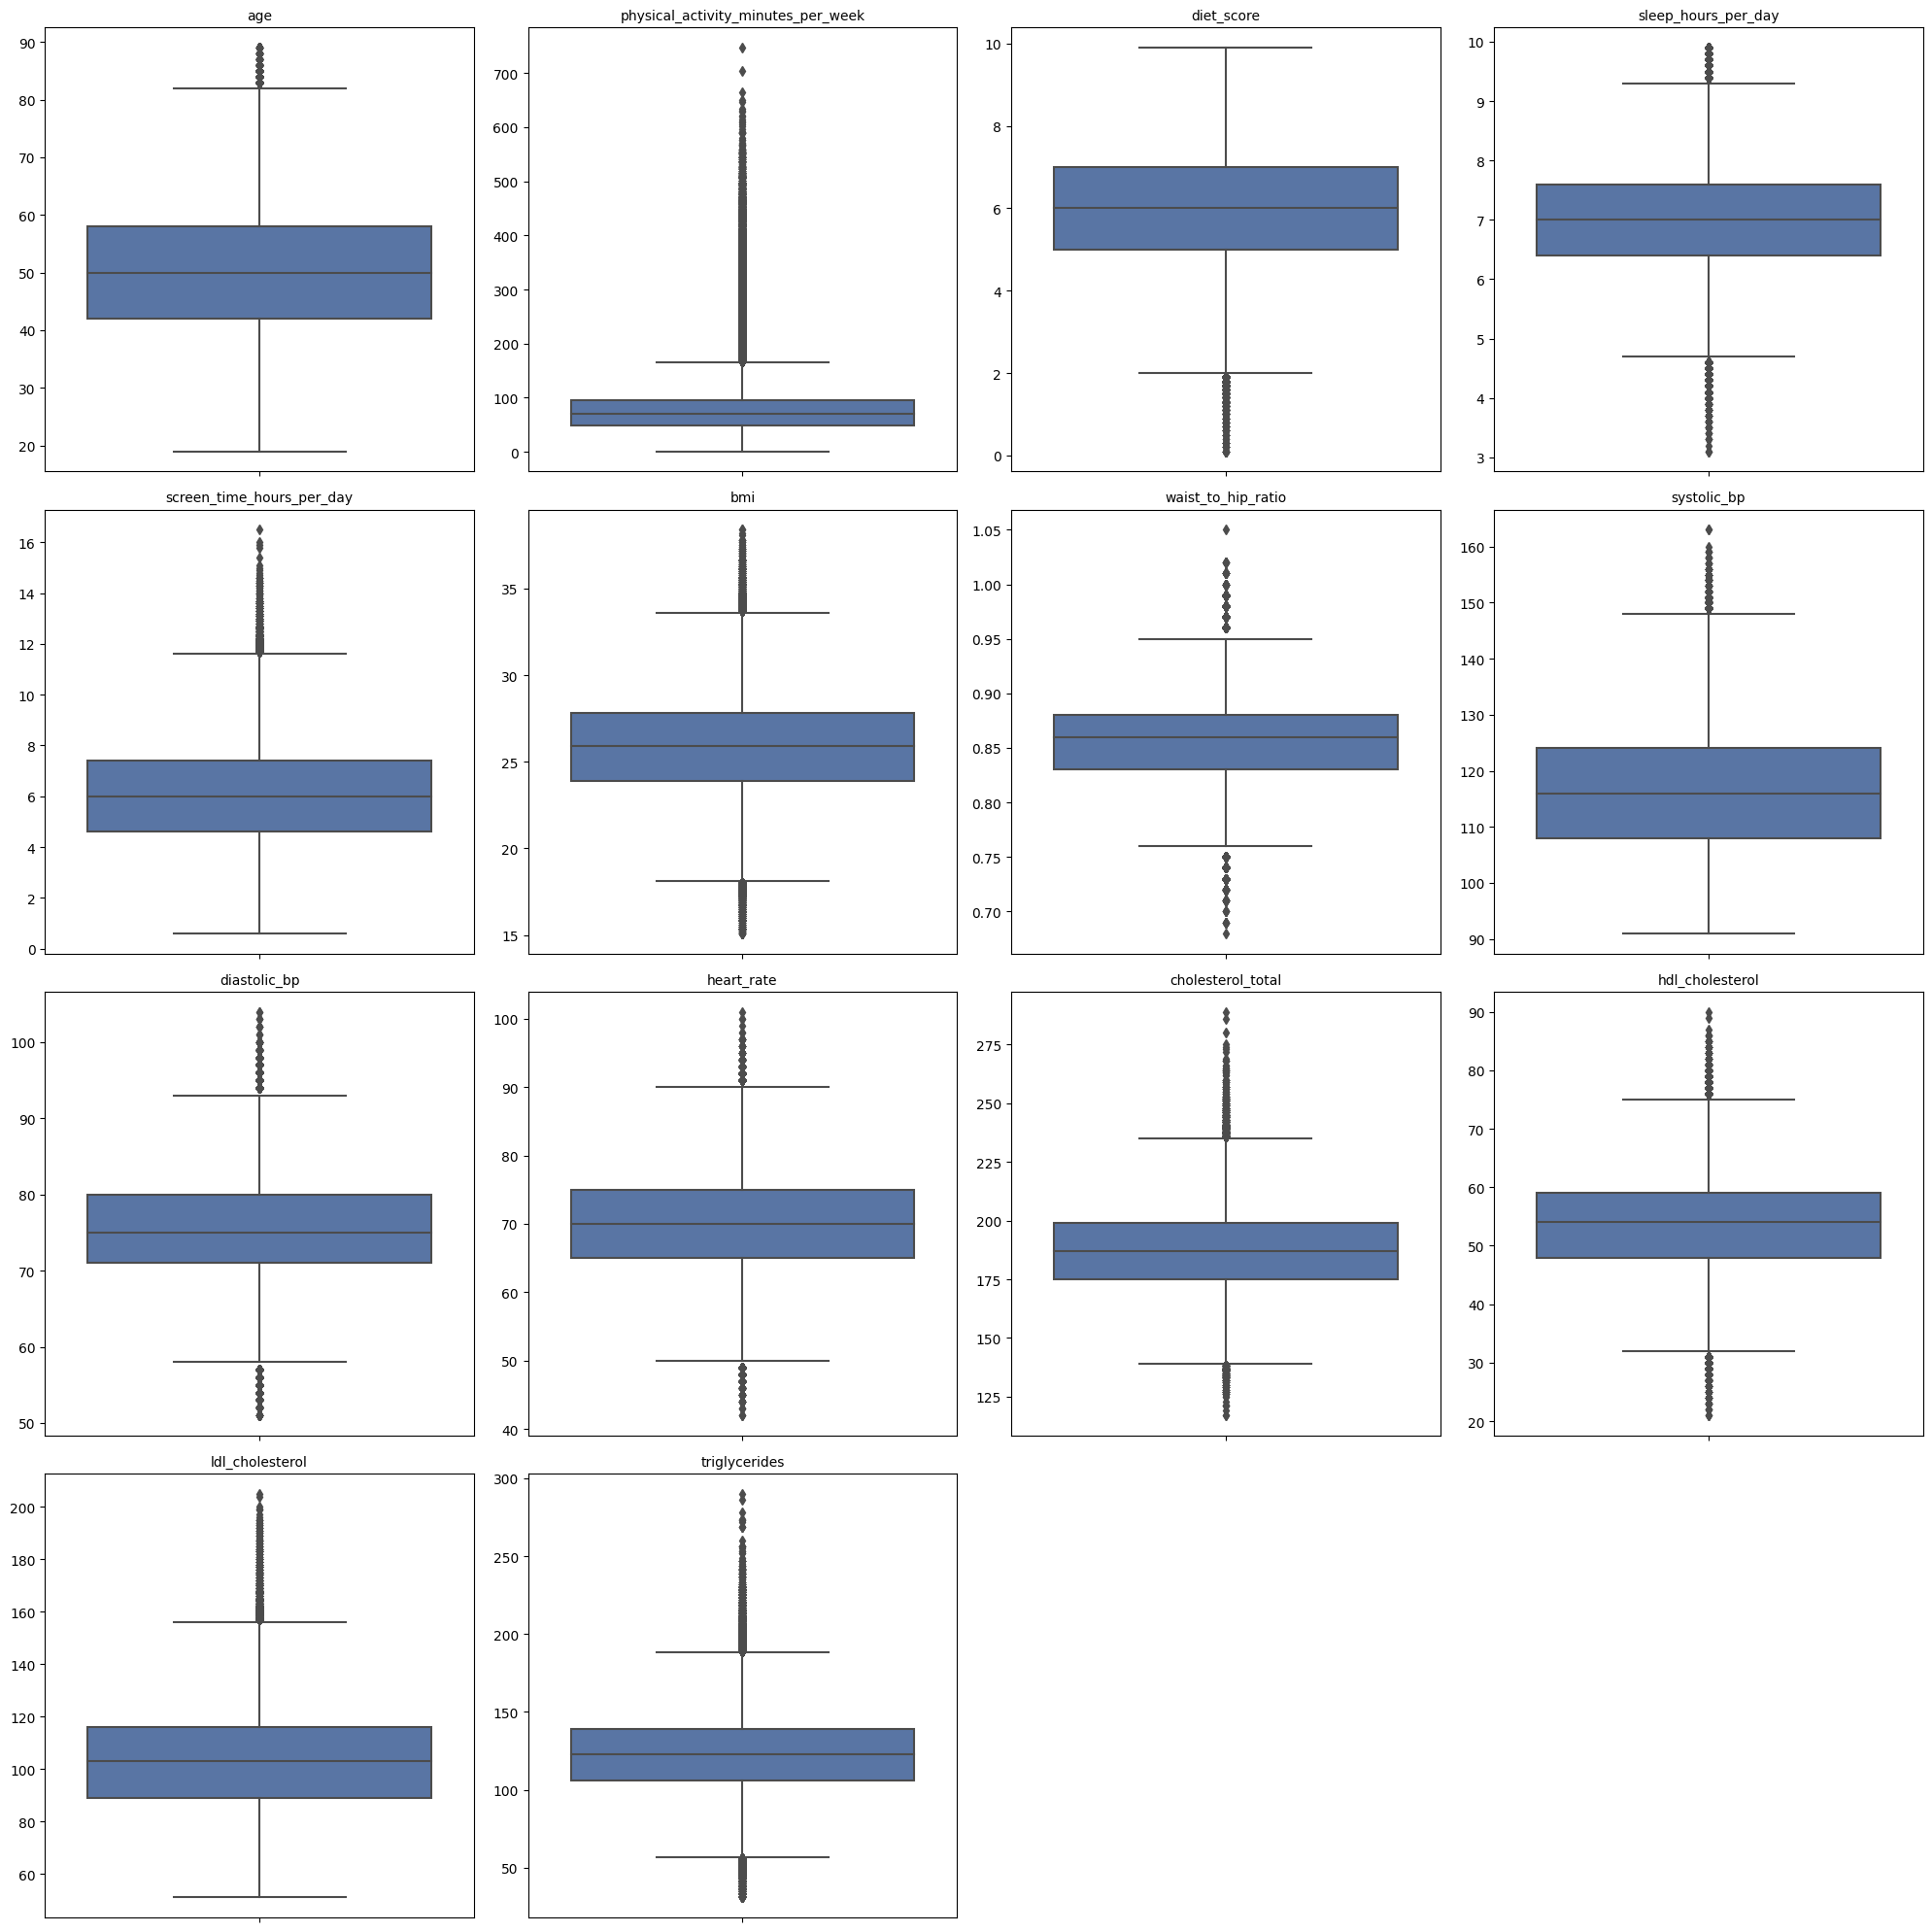

In [75]:
# Boxplots verticali per ogni feature numerica continua
n_cols = 4
n_rows = 4
plt.figure(figsize=(20, 20))

for i, col in enumerate(numeric_cols):
    plt.subplot(n_rows, n_cols, i + 1)
    
    sns.boxplot(y=df[col], color='#4C72B0')
    
    plt.title(col, fontsize=10)
    plt.ylabel('')

plt.tight_layout()
plt.show()

### 3.6 Categorical Features vs Target

Countplots with `hue=TARGET` reveal whether the diabetes rate varies across the levels
of each categorical / binary feature. Differences in within-category proportions are a
first indication of predictive value.

In [76]:
# Combine pure categoricals with the binary medical flags
cat_like = df.select_dtypes('object').columns.tolist() + binary_cols + ['alcohol_consumption_per_week']
print(f"Categorical-like features ({len(cat_like)}):", cat_like)

Categorical-like features (10): ['gender', 'ethnicity', 'education_level', 'income_level', 'smoking_status', 'employment_status', 'family_history_diabetes', 'hypertension_history', 'cardiovascular_history', 'alcohol_consumption_per_week']


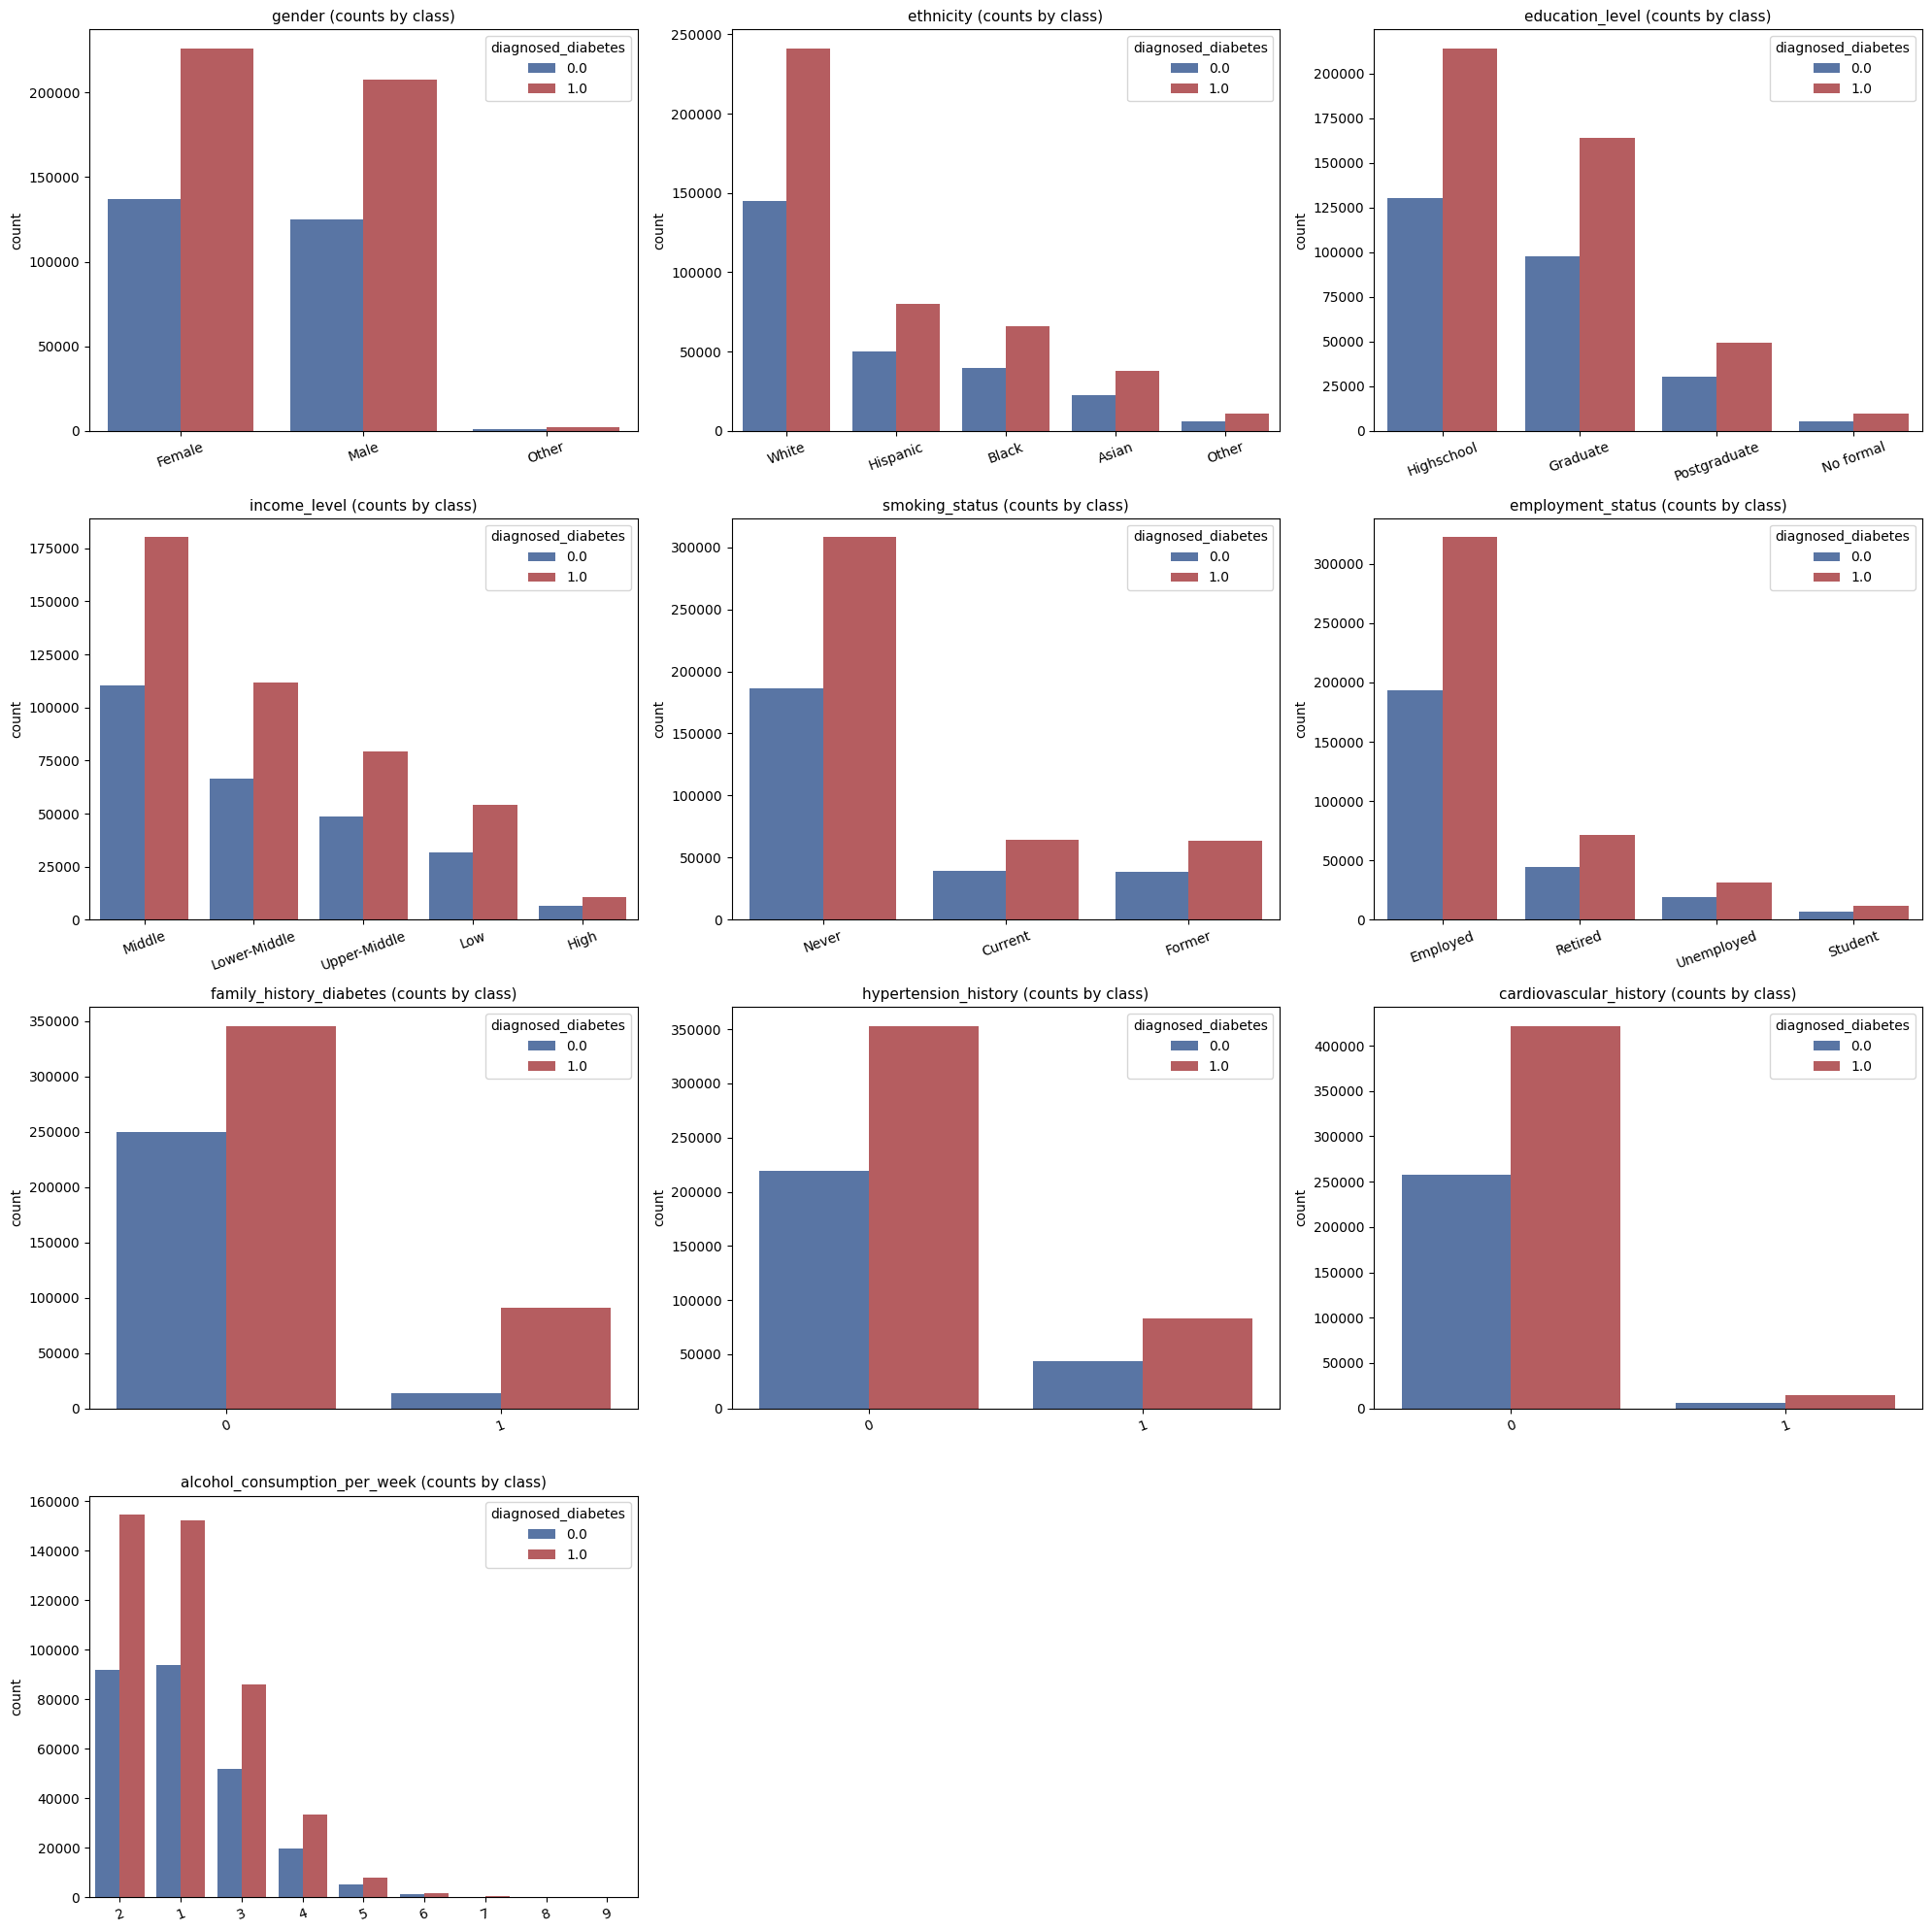

In [77]:
n_cols = 3
n_rows = 4
plt.figure(figsize=(20, 20))

for i, col in enumerate(cat_like):

    plt.subplot(n_rows, n_cols, i + 1)
    
    order = df[col].value_counts().index
    
    sns.countplot(x=col, hue=TARGET, data=df, order=order,
                  palette=['#4C72B0', '#C44E52'])
    
    plt.title(f'{col} (counts by class)', fontsize=11)
    plt.xlabel('')
    plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

**Observations:**

- `gender` displays **virtually identical class ratios across all levels** (the bars are proportionally uniform)
- `education_level` and `income_level` also show **minimal within-category differentiation**: the red bar dominates uniformly across all levels, with only a slight trend toward higher diabetes prevalence in lower-income and lower-education groups.
- `alcohol_consumption_per_week` is dominated by values 1–3, and the diabetic class outnumbers the non-diabetic at every level.

### 3.7 Numerical Features by Target Class

To see whether continuous features separate the two classes, we plot a **KDE per class**
for each feature. Features whose distributions are visibly shifted between class 0 and
class 1 carry direct predictive signal.

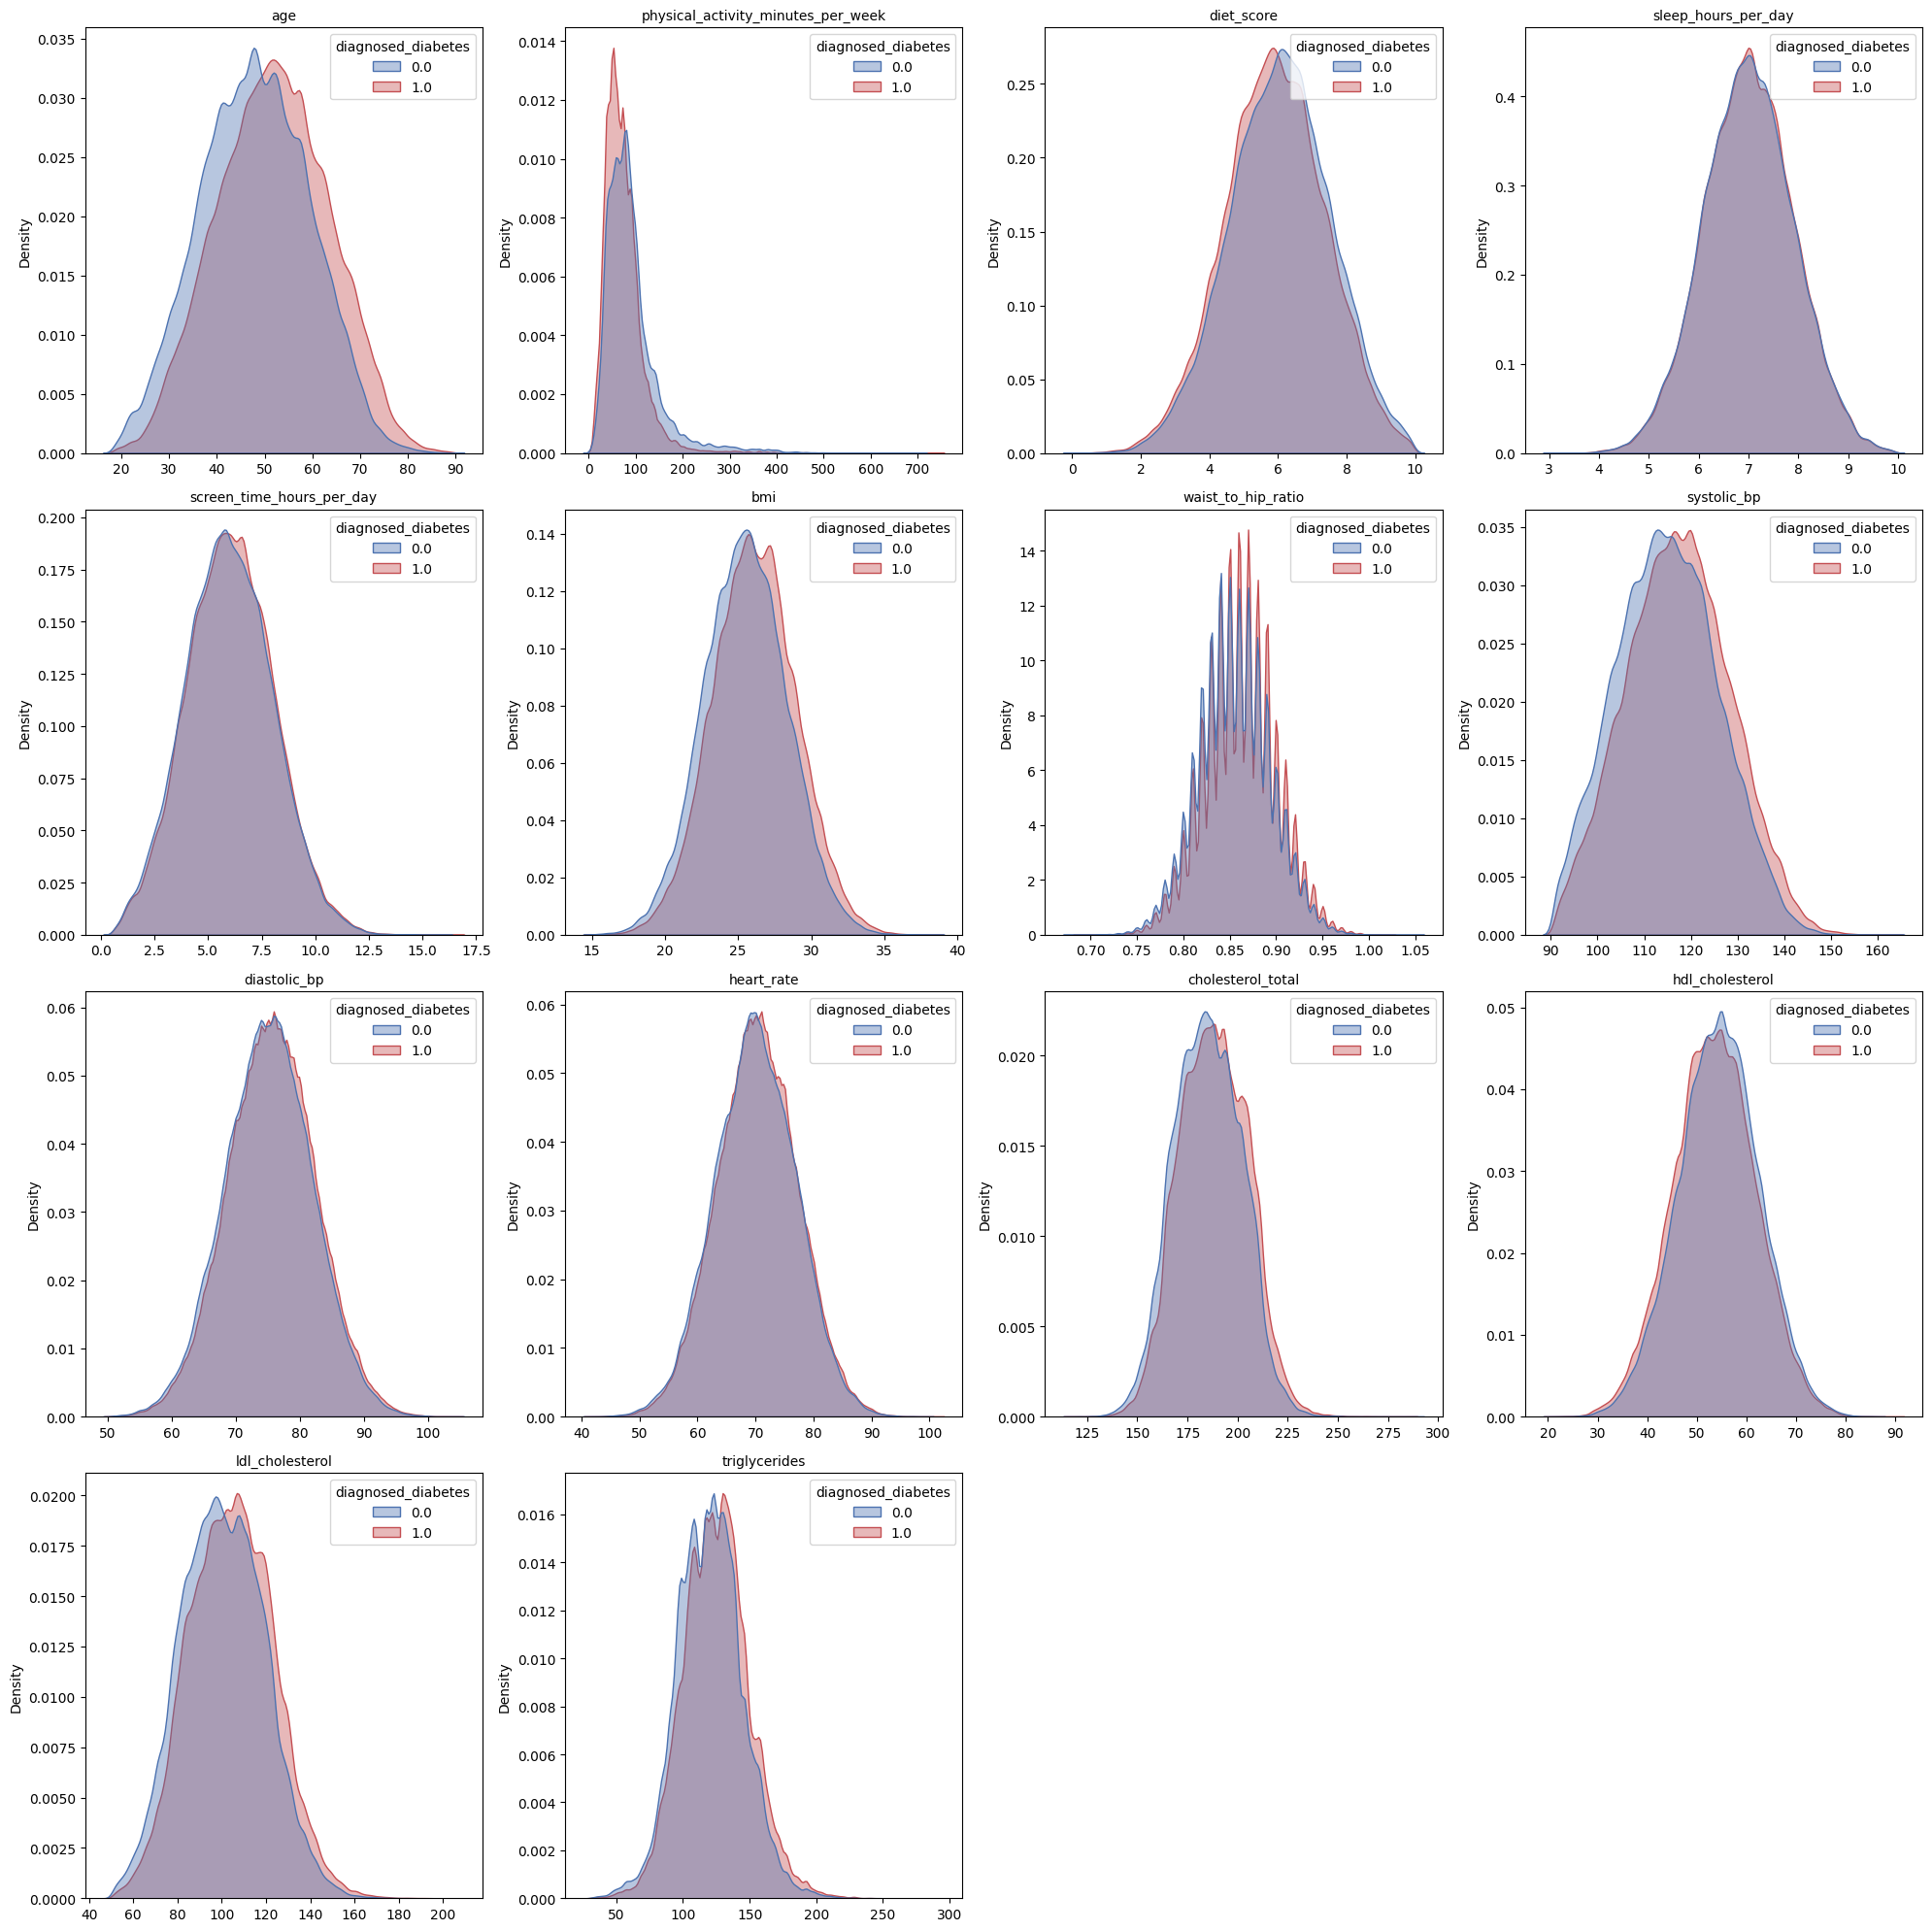

In [78]:
# KDE plot per class for each continuous numerical feature
n_cols = 4
n_rows = 4
plt.figure(figsize=(20, 20))

for i, col in enumerate(numeric_cols):
    # Attiva il subplot corrispondente (indice 1-based)
    plt.subplot(n_rows, n_cols, i + 1)
    
    # Seaborn disegna nel subplot corrente
    sns.kdeplot(data=df, x=col, hue=TARGET,
                common_norm=False, fill=True, alpha=0.4,
                palette=['#4C72B0', '#C44E52'])
    
    # Formattazione
    plt.title(col, fontsize=10)
    plt.xlabel('')

plt.tight_layout()
plt.show()

### 3.8 Correlation Analysis

A correlation heatmap helps detect:
- **redundant features** (very high pairwise correlations → multicollinearity),
- **direct signals to the target** (which feature correlates most with
  `diagnosed_diabetes`).

/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1


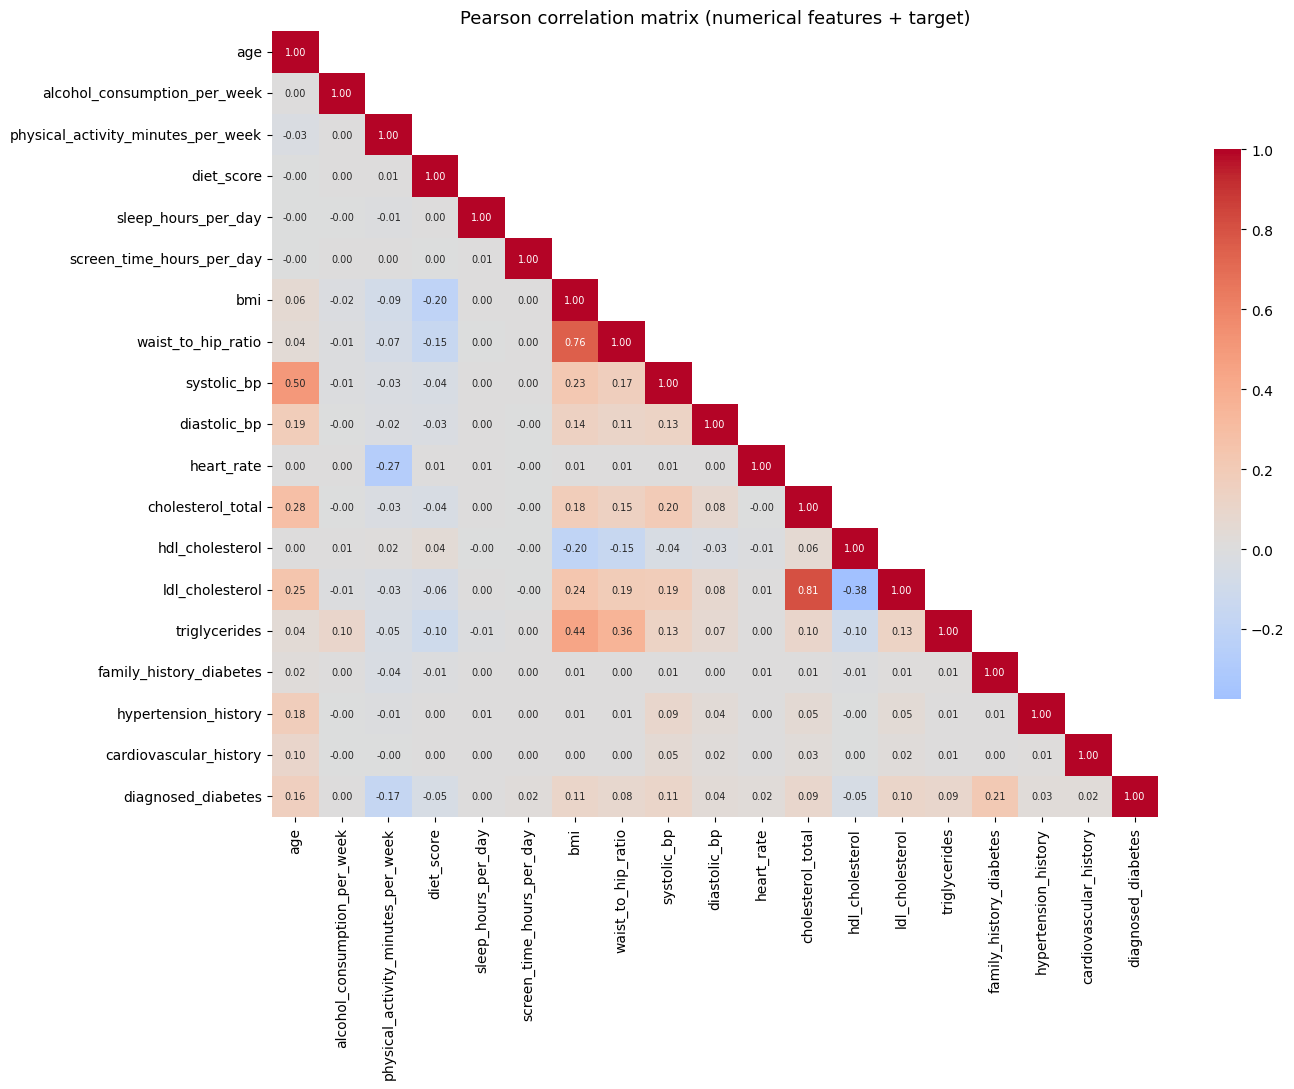

In [79]:
# Pearson correlation matrix for numeric features (binary flags + target included)
num_for_corr = [c for c in df.select_dtypes(include=['int64', 'float64']).columns
                if c != 'id']
corr = df[num_for_corr].corr()

plt.figure(figsize=(14, 11))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, cmap='coolwarm', center=0,
            annot=True, fmt='.2f', annot_kws={'size': 7},
            cbar_kws={'shrink': 0.7})
plt.title('Pearson correlation matrix (numerical features + target)', fontsize=13)
plt.tight_layout()
plt.show()

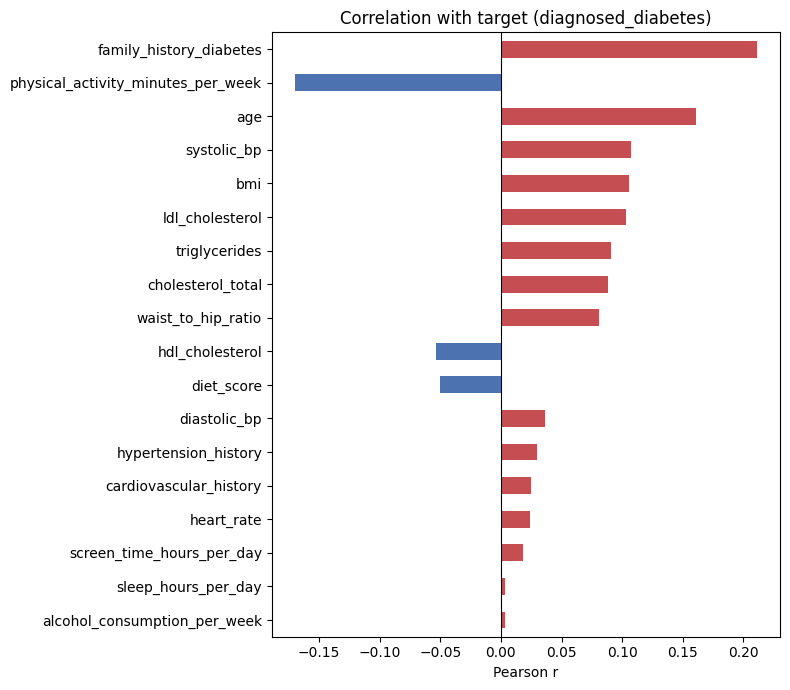

In [80]:
# Correlation of each feature with the target, sorted by absolute value
target_corr = (corr[TARGET]
                 .drop(TARGET)
                 .sort_values(key=abs, ascending=False))

fig, ax = plt.subplots(figsize=(8, 7))
colors = ['#C44E52' if v > 0 else '#4C72B0' for v in target_corr.values]
target_corr.plot(kind='barh', ax=ax, color=colors)
ax.invert_yaxis()
ax.set_title(f'Correlation with target ({TARGET})')
ax.set_xlabel('Pearson r')
ax.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

In [81]:
target_corr.round(3)

family_history_diabetes               0.211
physical_activity_minutes_per_week   -0.170
age                                   0.161
systolic_bp                           0.107
bmi                                   0.106
ldl_cholesterol                       0.103
triglycerides                         0.091
cholesterol_total                     0.088
waist_to_hip_ratio                    0.081
hdl_cholesterol                      -0.053
diet_score                           -0.050
diastolic_bp                          0.036
hypertension_history                  0.030
cardiovascular_history                0.025
heart_rate                            0.024
screen_time_hours_per_day             0.018
sleep_hours_per_day                   0.004
alcohol_consumption_per_week          0.003
Name: diagnosed_diabetes, dtype: float64

## **4. Preprocessing & Feature Engineering**

Based on the EDA conclusions, this section transforms the raw dataframe into a
**model-ready** matrix.

Pipeline:
1. Drop `id` (non-predictive).
2. Encode categorical variables (ordinal where applicable, one-hot otherwise).
3. Apply a robust scaler to continuous features (saved separately — tree models
   will use the unscaled version).

### 4.1 Drop the `id` column

`id` is a unique row identifier with no predictive value. We keep it aside in case it
is needed for joins later, but it must not enter the feature matrix.

In [82]:
print(f"Before dropping id: {df.shape}")
df_proc = df.drop(columns=['id']).copy()
print(f"After dropping id: {df_proc.shape}")

Before dropping id: (700000, 26)
After dropping id: (700000, 25)


### 4.3 Encoding of Categorical Features

- **Ordinal encoding** for variables with a clear order:
  - `education_level` : *No formal* < *Highschool* < *Graduate* < *Postgraduate*
  - `income_level`    : *Low* < *Lower-Middle* < *Middle* < *Upper-Middle* < *High*
- **One-hot encoding** for purely nominal variables:
  - `gender`, `ethnicity`, `smoking_status`, `employment_status`

The binary medical flags (`family_history_diabetes`, `hypertension_history`,
`cardiovascular_history`) are already 0/1 and require no encoding.

In [84]:
# Ordinal encoding
ordinal_cols = ['education_level', 'income_level']
ordinal_categories = [
    ['No formal', 'Highschool', 'Graduate', 'Postgraduate'], # education_level
    ['Low', 'Lower-Middle', 'Middle', 'Upper-Middle', 'High'], # income_level
]

ord_enc = OrdinalEncoder(categories=ordinal_categories, dtype=np.int8)
df_proc[ordinal_cols] = ord_enc.fit_transform(df_proc[ordinal_cols])

# One-hot encoding 
nominal_cols = ['gender', 'ethnicity', 'smoking_status', 'employment_status']

ohe = OneHotEncoder(drop=None, sparse_output=False, dtype=np.int8)
ohe_array   = ohe.fit_transform(df_proc[nominal_cols])
ohe_columns = ohe.get_feature_names_out(nominal_cols)

df_ohe  = pd.DataFrame(ohe_array, columns=ohe_columns, index=df_proc.index)
df_proc = pd.concat([df_proc.drop(columns=nominal_cols), df_ohe], axis=1)

print(f"Shape after encoding: {df_proc.shape}")
df_proc.dtypes.value_counts()

Shape after encoding: (700000, 36)


int8       17
int64      13
float64     6
Name: count, dtype: int64

## 11. References
- **Diabetes Prediction Challenge**: https://www.kaggle.com/competitions/playground-series-s5e12/data
- **Original Diabetes Health Indicators Dataset**: https://www.kaggle.com/datasets/mohankrishnathalla/diabetes-health-indicators-dataset/data